# Commodity Equity Alpha

The main approach in this model is examining and trading the relationship between physical producers / users equity alpha and commodities returns. The equity alpha for commodities producer is the excess return attribute to the individual companies. Equity investors may be attributing excess returns to commodity companies which the commodities market doesn't fully price in.

We'll first by using various commodity ETFs and their respective Commodity Futures. 

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

# Preparing data

In [2]:
df_eq = (pd.read_parquet(
    path = r"data/eq_px.parquet").
    query("variable == 'Adj Close'").
    pivot(index = "date", columns = "ticker", values = "value").
    pct_change().
    reset_index().
    melt(id_vars = ["date", "SPY"]).
    dropna())

In [3]:
df_fut = (pd.read_parquet(
    path = r"data/commod_px.parquet").
    assign(security = lambda x: x.security.str.split("1").str[0].str.strip()).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = ["date"], var_name = "fut_ticker", value_name = "fut_rtn").
    dropna().
    assign(date = lambda x: pd.to_datetime(x.date).dt.date))

In [4]:
df_relationship = pd.read_excel(io = r"data/tickers.xlsx", sheet_name = "relationship")

In [5]:
df_ticker = (pd.read_excel(
    io         = r"data/tickers.xlsx", 
    sheet_name = "relationship").
    assign(
        tmp       = lambda x: x.Name.str.replace("VanEck", "").str.replace("ETF", "").str.replace("and", "&").str.replace("Metals", ""),
        group_var = lambda x: x.Ticker + " " + x.fut_ticker))

# Building out the model

First start by seperating out the alpha in equities. In this case use a 30 day rolling OLS regression and SPY as a benchmark. 

In [6]:
def _get_ols(df: pd.DataFrame, window: int = 30) -> pd.DataFrame: 
    
    df_out = (RollingOLS(
        endog  = df.value,
        exog   = sm.add_constant(df.SPY),
        window = window).
        fit().
        params.
        rename(columns = {"SPY": "beta"}).
        merge(right = df, how = "inner", on = ["date"]))
    
    return df_out

In [7]:
df_alpha = (df_eq.set_index(
    "date").
    groupby("ticker").
    apply(_get_ols, include_groups = False).
    reset_index().
    dropna())

Below is the rolling alphas of the commodity etfs to the SPY.

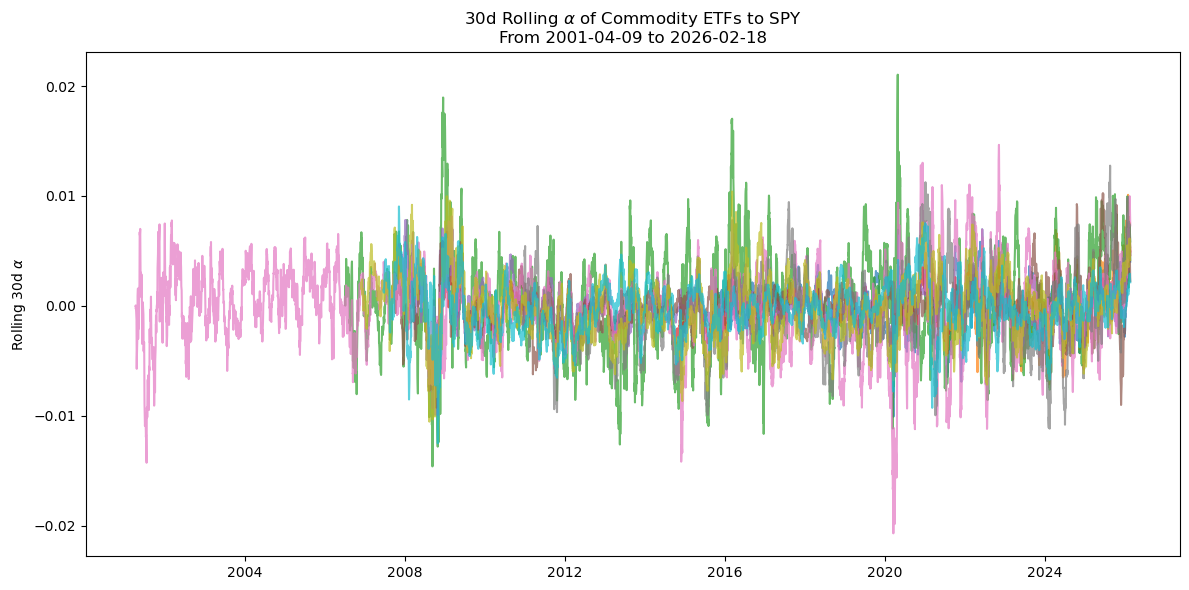

In [8]:
(df_alpha.pivot(
    index = "date", columns = "ticker", values = "const").
    plot(
        ylabel  = r"Rolling 30d $\alpha$",
        legend  = False,
        xlabel  = "",
        figsize = (12,6),
        alpha   = 0.7,
        title   = r"30d Rolling $\alpha$ of Commodity ETFs to SPY" + "\nFrom {} to {}".format(
            df_alpha.date.min(),
            df_alpha.date.max())))

plt.tight_layout()

In [9]:
df_combined = (df_relationship.rename(
    columns = {"Ticker": "ticker"}).
    assign(Name = lambda x: x.Name.str.replace("VanEck", "").str.replace("ETF", "")).
    merge(right = df_alpha, how = "inner", on = ["ticker"]).
    merge(right = df_fut, how = "inner", on = ["fut_ticker", "date"]))

In [10]:
def _get_resid(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 
    
    df_tmp = df.sort_index()
    df_out = (sm.OLS(
        endog  = df_tmp.fut_rtn,
        exog   = sm.add_constant(df_tmp.const)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = q, labels = [i + 1 for i in range(q)]).shift()).
        merge(right = df, how = "inner", on = ["date"]))
    
    return df_out

df_signal = (df_combined.assign(
    group_var = lambda x: x.ticker + " " + x.fut_ticker).
    set_index("date").
    groupby("group_var").
    apply(_get_resid, include_groups = False).
    reset_index())

In [11]:
def _model(df: pd.DataFrame) -> pd.DataFrame: 
    
    df_tmp = df.sort_index()
    model1 = (sm.OLS(
        endog  = df_tmp.fut_rtn,
        exog   = sm.add_constant(df_tmp.alpha)).
        fit())
    
    df_param_val = (model1.params.to_frame(
        name = "param_val").reset_index())
    
    df_pvalue = (model1.pvalues.to_frame(
        name = "pvalue").reset_index())
    
    df_tstat = (model1.tvalues.to_frame(
        name = "tstat").reset_index())
    
    df_out = (df_param_val.merge(
        right = df_pvalue, how = "inner", on = ["index"]).
        merge(right = df_tstat, how = "inner", on = ["index"]))
    
    return df_out

def _get_coefs(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 
    
    df_lag0 = _model(df).assign(model = "lag_0")
    df_lag  = df.sort_index().assign(alpha = lambda x: x.alpha.shift()).dropna()
    df_lag1 = _model(df_lag).assign(model = "lag_1")
    
    df_out = pd.concat([df_lag0, df_lag1])
    return df_out

df_coefs = (df_combined.assign(
    group_var = lambda x: x.ticker + " " + x.fut_ticker).
    set_index("date").
    rename(columns = {"const": "alpha"}).
    groupby("group_var").
    apply(_get_coefs))

Then we pass those rolling alphas into a regression against their respective commodities. Below is the results of that regression

In [12]:
(df_coefs.reset_index().drop(
    columns = ["level_1"]).
    assign(
        ticker     = lambda x: x.group_var.str.split(" ").str[0],
        fut_ticker = lambda x: x.group_var.str.split(" ").str[1]).
    drop(columns = ["group_var"]).
    rename(columns = {"index": "param"}).
    melt(id_vars = ["param", "fut_ticker", "model", "ticker"]).
    replace({
        "param_val": "Param. Val",
        "pvalue"   : "p-value",
        "tstat"    : "t-stat",
        "lag_0"    : "No-Lag",
        "lag_1"    : "Lagged",
        "alpha"    : r"Equity $\alpha$"}).
    pivot(index = ["fut_ticker", "ticker", "param"], columns = ["variable", "model"], values = "value").
    apply(lambda x: np.round(x,3)))

variable                          Param. Val        p-value         t-stat  \
model                                 No-Lag Lagged  No-Lag Lagged  No-Lag   
fut_ticker ticker param                                                      
BO         MOO    Equity $\alpha$      0.698  0.375   0.000  0.006   5.082   
                  const                0.000  0.000   0.158  0.228   1.410   
CC         MOO    Equity $\alpha$      0.278  0.152   0.129  0.405   1.517   
                  const                0.001  0.001   0.063  0.072   1.861   
CL         OIH    Equity $\alpha$      1.420  1.164   0.000  0.000   7.138   
                  const                0.000  0.000   0.889  0.983   0.140   
CO         OIH    Equity $\alpha$      0.848  0.367   0.000  0.000  10.915   
                  const                0.001  0.001   0.008  0.039   2.667   
CT         MOO    Equity $\alpha$      0.480  0.308   0.001  0.041   3.188   
                  const                0.000  0.000   0.381  0.437   0.876   
FC         MOO    Equity $\alpha$     -0.027 -0.008   0.741  0.926  -0.330   
                  const                0.000  0.000   0.578  0.560   0.556   
GC         GDX    Equity $\alpha$      0.391  0.055   0.000  0.151  10.238   
                  const                0.000  0.000   0.076  0.027   1.775   
HG         EMET   Equity $\alpha$      0.707  0.133   0.000  0.481   3.787   
                  const                0.001  0.000   0.348  0.481   0.939   
HO         CRAK   Equity $\alpha$      0.884  0.417   0.000  0.055   4.085   
                  const                0.001  0.001   0.112  0.123   1.592   
KC         MOO    Equity $\alpha$      0.074 -0.145   0.681  0.419   0.412   
                  const                0.000  0.000   0.320  0.379   0.994   
LC         MOO    Equity $\alpha$      0.059  0.010   0.496  0.906   0.681   
                  const                0.000  0.000   0.467  0.497   0.727   
LH         MOO    Equity $\alpha$      0.124  0.075   0.380  0.593   0.877   
                  const                0.000  0.000   0.460  0.471   0.739   
NG         CRAK   Equity $\alpha$     -0.280 -0.328   0.414  0.339  -0.817   
                  const                0.001  0.001   0.357  0.359   0.921   
QS         CRAK   Equity $\alpha$      0.903  0.412   0.000  0.042   4.470   
                  const                0.001  0.001   0.273  0.261   1.097   
S          MOO    Equity $\alpha$      0.541  0.230   0.000  0.058   4.469   
                  const                0.001  0.000   0.015  0.027   2.428   
SB         MOO    Equity $\alpha$      0.418  0.224   0.015  0.192   2.436   
                  const                0.000  0.000   0.273  0.316   1.096   
SM         MOO    Equity $\alpha$      0.432  0.175   0.002  0.210   3.090   
                  const                0.001  0.001   0.003  0.006   2.926   
W          MOO    Equity $\alpha$      0.484  0.245   0.006  0.162   2.763   
                  const               -0.000 -0.000   0.550  0.479  -0.597   
XB         CRAK   Equity $\alpha$      1.007  0.493   0.000  0.042   4.178   
                  const                0.001  0.001   0.048  0.053   1.975   

variable                                  
model                             Lagged  
fut_ticker ticker param                   
BO         MOO    Equity $\alpha$  2.729  
                  const            1.207  
CC         MOO    Equity $\alpha$  0.832  
                  const            1.798  
CL         OIH    Equity $\alpha$  5.838  
                  const            0.021  
CO         OIH    Equity $\alpha$  4.681  
                  const            2.062  
CT         MOO    Equity $\alpha$  2.041  
                  const            0.777  
FC         MOO    Equity $\alpha$ -0.093  
                  const            0.582  
GC         GDX    Equity $\alpha$  1.435  
                  const            2.206  
HG         EMET   Equity $\alpha$  0.706  
                  const    

In [13]:
df_signal_rtn = (df_signal.assign(
    signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn).
    query("ticker != 'EMET'").
    rename(columns = {"group_var": ""}).
    pivot(index = "date", columns = "", values = "signal_rtn").
    dropna().
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    assign(Average = lambda x: x.mean(axis = 1)))

Here is the results of trading the residuals of that regression

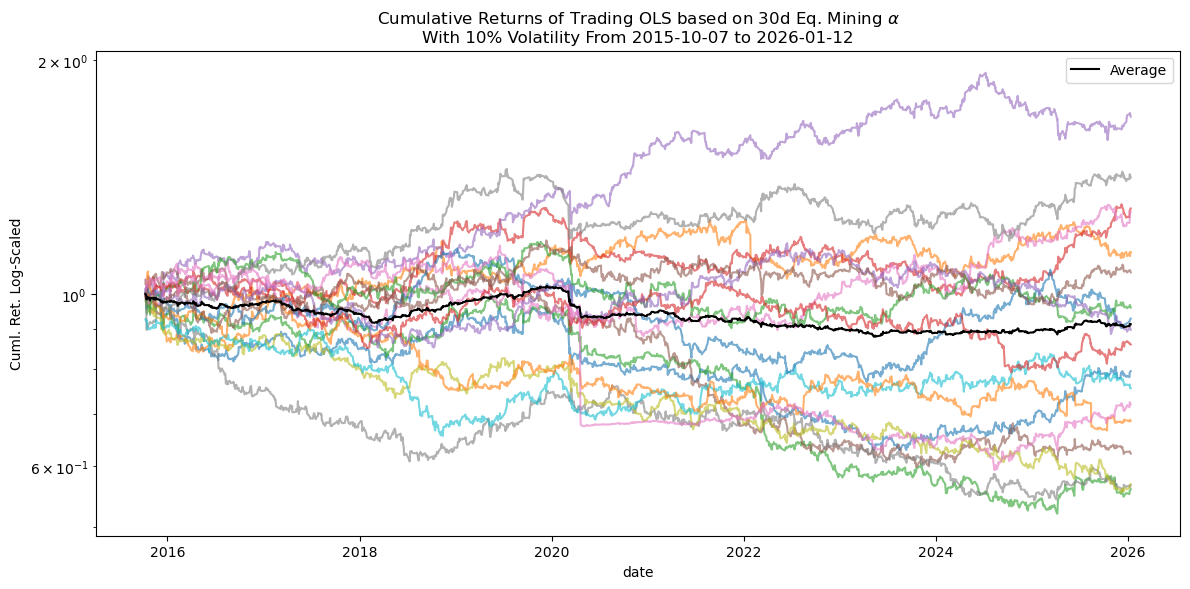

In [14]:
fig, axes = plt.subplots(figsize = (12,6))

(df_signal_rtn.drop(
    columns = ["Average"]).
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        ax     = axes,
        logy   = True,
        alpha  = 0.6,
        legend = False))

(df_signal_rtn[
    ["Average"]].
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        logy   = True, 
        ax     = axes,
        color  = "black",
        ylabel = "Cuml. Ret. Log-Scaled",
        title  = "Cumulative Returns of Trading OLS based on " + r"30d Eq. Mining $\alpha$" + "\nWith 10% Volatility From {} to {}".format(
            df_signal_rtn.index.min(),
            df_signal_rtn.index.max())))

plt.tight_layout()

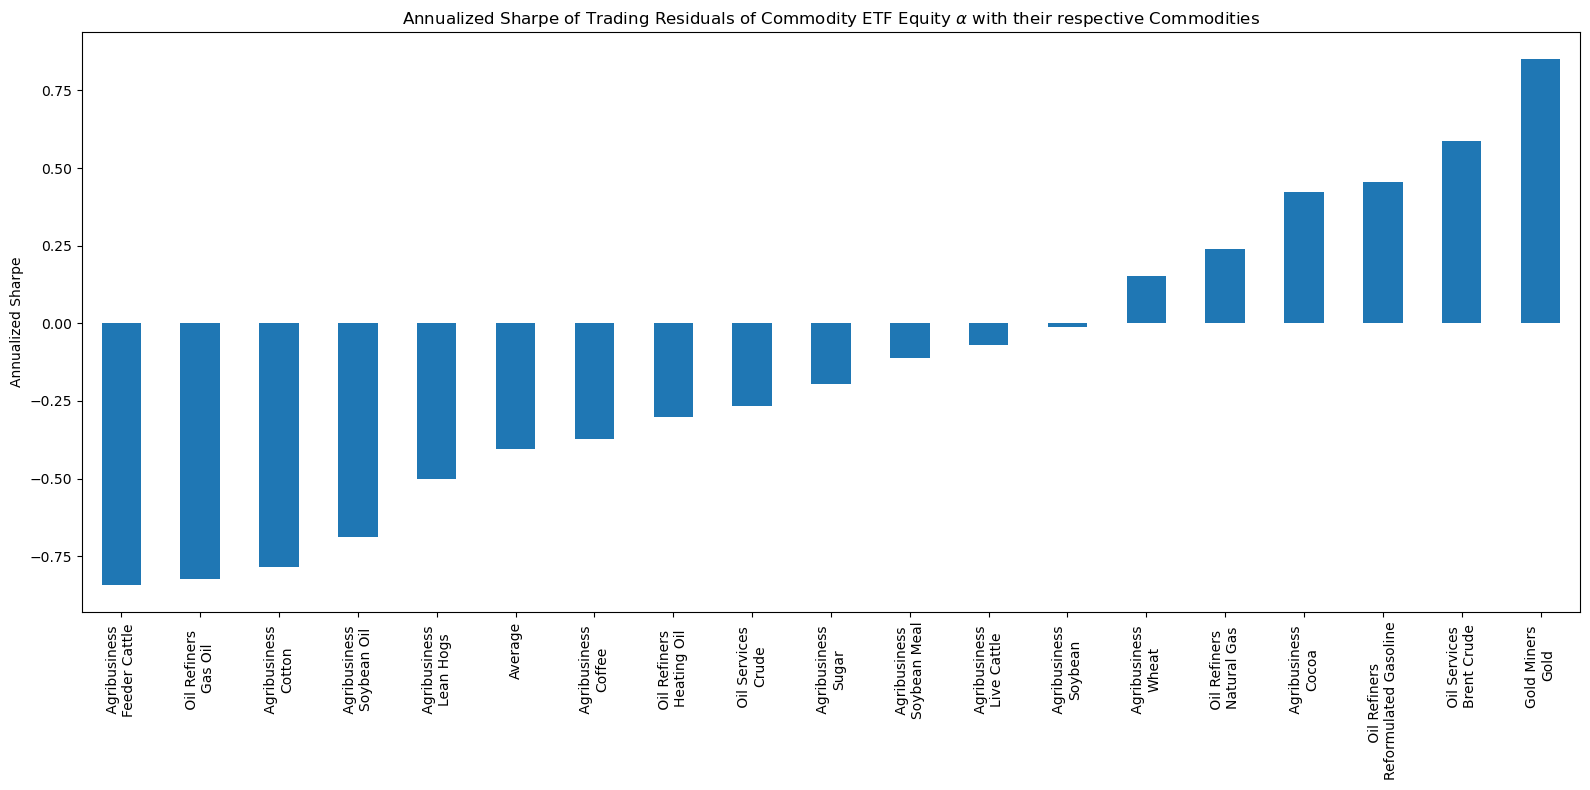

In [15]:
(df_signal_rtn.agg(
    lambda x: x.mean() / x.std() * np.sqrt(252)).
    to_frame(name = "sharpe").
    reset_index().
    rename(columns = {"": "group_var"}).
    merge(right = df_ticker, how = "left", on = ["group_var"]).
    assign(name = lambda x: (x.tmp + "\n" + x.fut_name).fillna(x.group_var)).
    set_index("name")
    [["sharpe"]].
    sort_values("sharpe").
    plot(
        kind    = "bar", 
        figsize = (16,8),
        xlabel  = "",
        ylabel  = "Annualized Sharpe",
        legend  = False,
        title   = r"Annualized Sharpe of Trading Residuals of Commodity ETF Equity $\alpha$ with their respective Commodities"))

plt.tight_layout()

In [16]:
df_signal_wider = (df_signal.assign(
    signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn).
    pivot(index = "date", columns = ["Name", "fut_name"], values = "signal_rtn"))

In [17]:
df_rsk_rtn = (df_signal_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "rtn").
    rename(columns = {("date", ""): "date"}).
    dropna().
    assign(group = "vol_hedged"))

In [18]:
df_perf_rtn = (df_signal_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "rtn").
    rename(columns = {("date", ""): "date"}).
    dropna().
    assign(group = "perf_hedged"))

In [19]:
df_date = (df_rsk_rtn[
    ["date", "Name", "fut_name"]].
    groupby(["Name", "fut_name"]).
    agg("min").
    reset_index())

Also account for volatility targetting done perfectly this is for representing intraday volatility targetting

In [20]:
display(pd.concat([
    df_rsk_rtn, df_perf_rtn]).
    drop(columns = ["date"]).
    groupby(["Name", "fut_name", "group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    pivot(index = ["Name", "fut_name"], columns = "group", values = "rtn").
    apply(lambda x: np.round(x,3)).
    reset_index().
    merge(right = df_date, how = "inner", on = ["Name", "fut_name"])
    [["date", "Name", "fut_name", "vol_hedged", "perf_hedged"]].
    rename(columns = {
        "date"       : "Start Date",
        "fut_name"   : "Fut",
        "vol_hedged" : "Vol Targatted",
        "perf_hedged": "Perfectly Targetted"}))

,Start Date,Name,Fut,Vol Targatted,Perfectly Targetted
0,2007-10-22,Agribusiness,Cocoa,0.112,0.126
1,2007-10-22,Agribusiness,Coffee,0.155,0.189
2,2007-10-22,Agribusiness,Cotton,-0.521,-0.501
3,2007-10-22,Agribusiness,Feeder Cattle,-1.265,-1.280
4,2007-10-22,Agribusiness,Lean Hogs,-1.026,-1.028
5,2007-10-22,Agribusiness,Live Cattle,-0.281,-0.167
6,2007-10-22,Agribusiness,Soybean,-0.250,-0.226
7,2007-10-22,Agribusiness,Soybean Meal,-0.169,-0.162
8,2007-10-22,Agribusiness,Soybean Oil,-0.529,-0.520
9,2007-10-22,Agribusiness,Sugar,-0.302,-0.289


In [21]:
df_decile_sharpe = (df_signal[
    ["group_var", "decile", "fut_rtn"]].
    dropna().
    groupby(["group_var", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"fut_rtn": "sharpe"}))

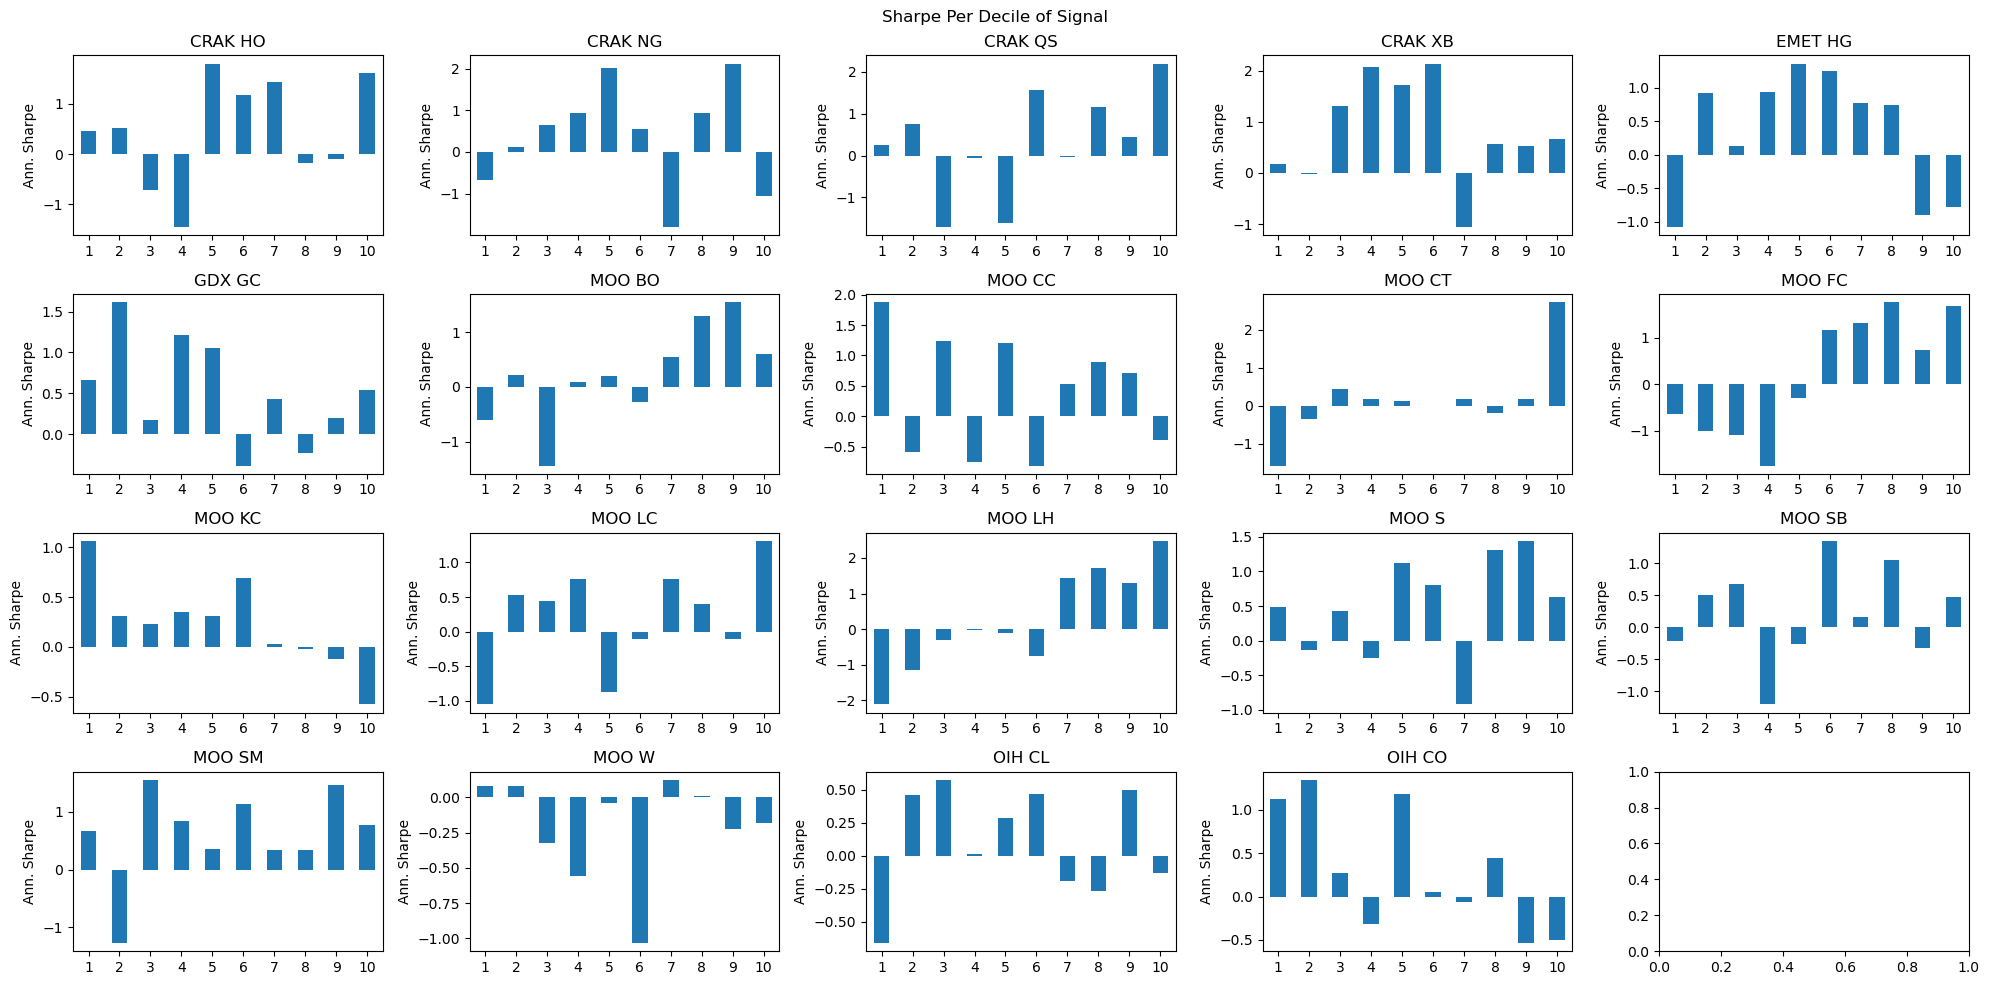

In [22]:
groups_vars = df_decile_sharpe.group_var.drop_duplicates().sort_values().to_list()
fig, axes   = plt.subplots(ncols = 5, nrows = 4, figsize = (20,10))

for group_var, ax in zip(groups_vars, axes.flatten()):
    
    (df_decile_sharpe.query(
        "group_var == @group_var").
        set_index("decile")
        [["sharpe"]].
        plot(
            kind   = "bar",
            ax     = ax,
            title  = group_var,
            legend = False,
            ylabel = "Ann. Sharpe",
            xlabel = "",
            rot    = 0))
    
fig.suptitle("Sharpe Per Decile of Signal")
plt.tight_layout()

In [23]:
df_grouper = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lower", "upper")))

In [24]:
df_opt_signal = (df_grouper[
    ["group_var", "group", "sharpe"]].
    assign(sharpe = lambda x: np.where(np.abs(x.sharpe) > 0.2, x.sharpe, 0)).
    groupby(["group_var", "group"]).
    agg("prod").
    reset_index().
    assign(scaler = lambda x: np.where(x.sharpe > 0, 1, np.nan)).
    drop(columns = ["sharpe"]).
    merge(right = df_grouper, how = "inner", on = ["group_var", "group"]).
    assign(signal = lambda x: x.scaler * x.sharpe).
    dropna())

In [25]:
df_opt_rtn = (df_signal.merge(
    right = df_opt_signal, how = "right", on = ["decile", "group_var"]).
    assign(signal_rtn = lambda x: np.sign(x.signal) * x.fut_rtn))

In [26]:
df_opt_rsk_rtn = (df_opt_rtn.pivot(
    index = "date", columns = "group_var", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date").
    assign(
        group  = lambda x: x.group_var.str.split(" ").str[0],
        ticker = lambda x: x.group_var.str.split(" ").str[1]).
    dropna())

In [27]:
renamer = (df_signal[
    ["ticker", "Name"]].
    assign(Name = lambda x: x.Name.str.strip()).
    drop_duplicates().
    set_index("ticker").
    Name.
    to_dict())

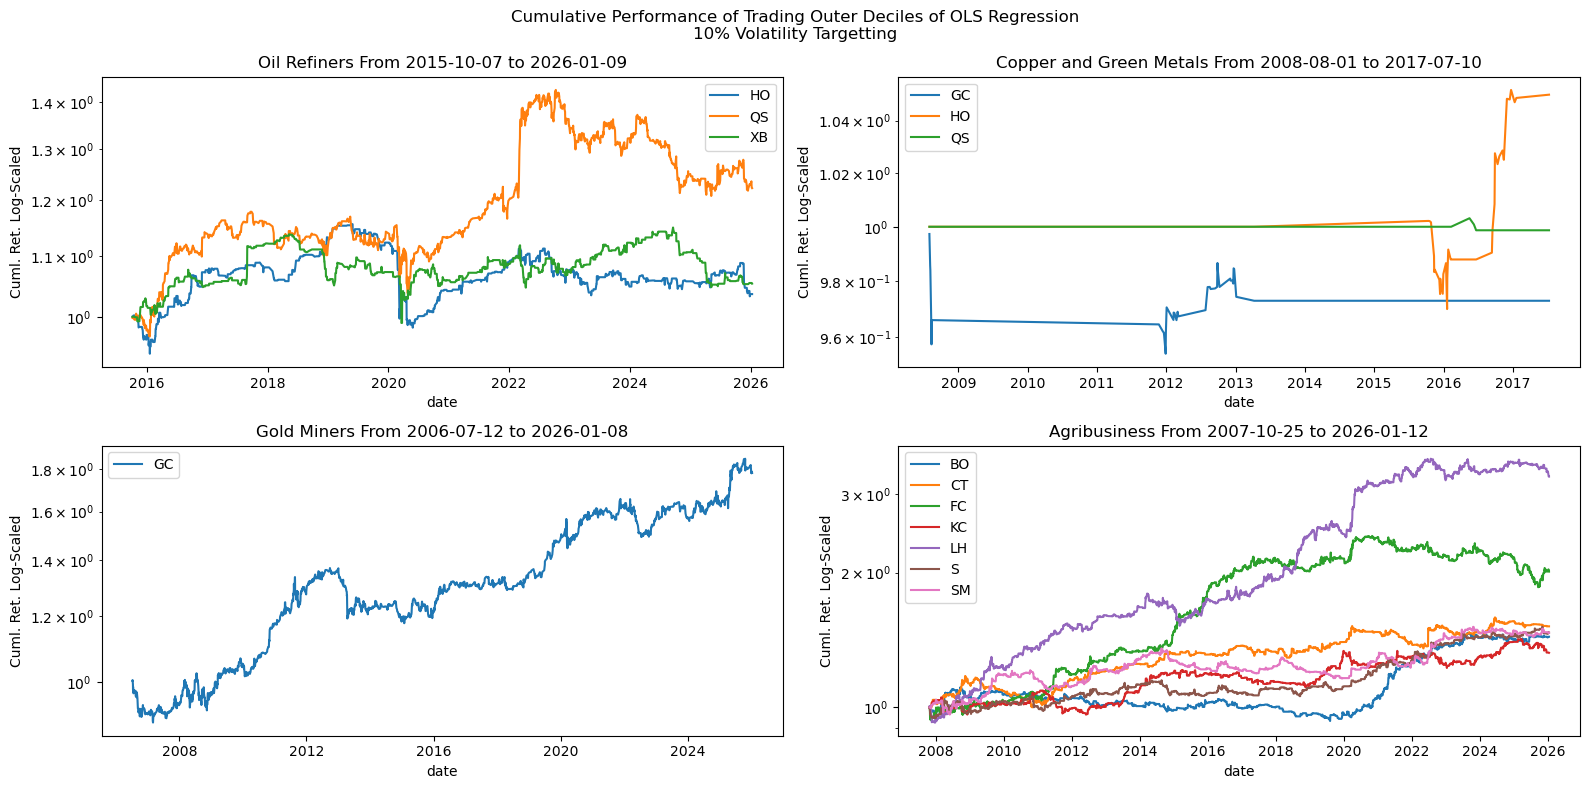

In [28]:
groups    = df_opt_rsk_rtn.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (16,8))

for group, ax in zip(groups, axes.flatten()): 
    
    df_tmp = (df_opt_rsk_rtn.query(
        "group == @group").
        rename(columns = {"ticker": ""}).
        query("value <= 0.4").
        pivot(index = "date", columns = "", values = "value").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)))
    
    (df_tmp.
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = "{} From {} to {}".format(
                renamer[group],
                df_tmp.index.min(),
                df_tmp.index.max())))
    
fig.suptitle("Cumulative Performance of Trading Outer Deciles of OLS Regression\n10% Volatility Targetting")
plt.tight_layout()

In [29]:
df_opt_rtn_wider = (df_opt_rtn.pivot(
    index = "date", columns = "group_var", values = "signal_rtn"))

In [30]:
df_lag1 = (df_opt_rtn_wider.
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date").
    assign(
        raw_rtn = lambda x: x.value.fillna(0),
        group   = "lag_1").
    rename(columns = {"value": "adj_rtn"}))

df_lag0 = (df_opt_rtn_wider.
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std()* np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date").
    assign(
        raw_rtn = lambda x: x.value.fillna(0),
        group   = "lag_0").
    rename(columns = {"value": "adj_rtn"}))

In [31]:
df_namer = (df_signal[
    ["group_var", "Name", "fut_ticker"]].
    drop_duplicates())

In [32]:
(pd.concat([
    df_lag1, df_lag0]).
    melt(id_vars = ["date", "group_var", "group"]).
    dropna().
    drop(columns = ["date"]).
    merge(right = df_namer, how = "inner", on = ["group_var"]).
    drop(columns = ["group_var"]).
    groupby(["Name", "fut_ticker", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"     : "Target Type",
        "fut_ticker": "Fut",
        "variable"  : ""}).
    replace({
        "lag_0"   : "Perfect Targetting",
        "lag_1"   : "Vol Targetting",
        "adj_rtn" : "Adj. Ret",
        "raw_rtn" : "Raw Return"}).
    pivot(index = ["Name", "Fut"], columns = ["Target Type", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Target Type                   Perfect Targetting            Vol Targetting  \
                                        Adj. Ret Raw Return       Adj. Ret   
Name                      Fut                                                
 Agribusiness             BO               0.760      0.320          1.032   
                          CT               1.042      0.438          1.133   
                          FC               1.037      0.617          0.978   
                          KC               0.897      0.377          0.784   
                          LH               1.752      1.040          1.689   
                          S                1.096      0.461          1.103   
                          SM               1.061      0.446          1.095   
 Copper and Green Metals  HG               1.118      0.220         -0.105   
 Oil Refiners             HO               0.429      0.126          0.248   
                          QS               0.679      0.308          0.540   
                          XB               0.252      0.074          0.351   
 Oil Services             CO               1.135      0.794          1.021   
Gold Miners               GC               0.912      0.562          0.781   

Target Type                               
                              Raw Return  
Name                      Fut             
 Agribusiness             BO       0.434  
                          CT       0.476  
                          FC       0.582  
                          KC       0.330  
                          LH       1.002  
                          S        0.464  
                          SM       0.460  
 Copper and Green Metals  HG      -0.021  
 Oil Refiners             HO       0.073  
                          QS       0.245  
                          XB       0.103  
 Oil Services             CO       0.714  
Gold Miners               GC       0.481

Text(0.5, 1.0, 'Correlation Matrix amongst decile-optimized signal')

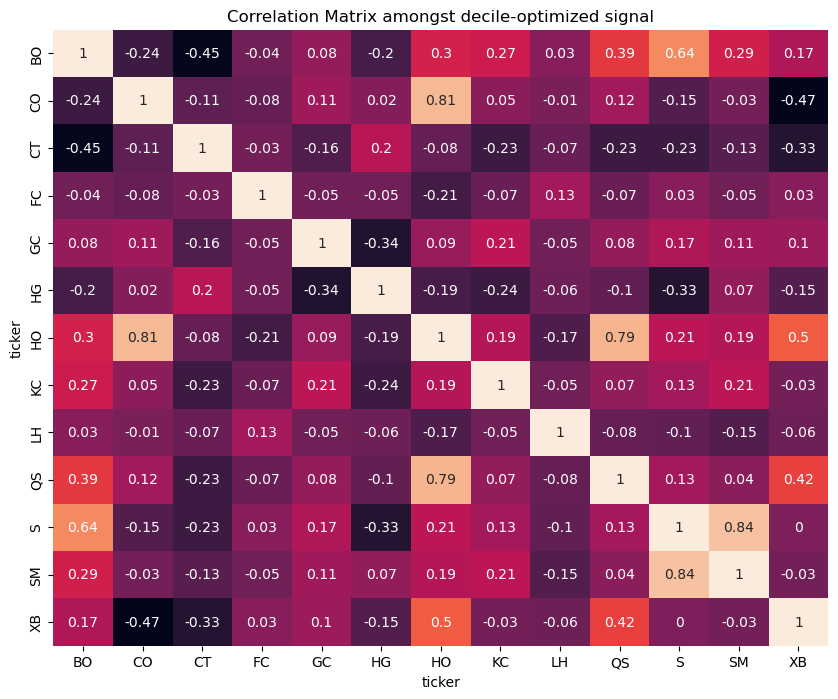

In [33]:
df_corr = (df_opt_rsk_rtn.pivot(
    index = "date", columns = "ticker", values = "value").
    corr().
    apply(lambda x: np.round(x,2)))

fig, axes = plt.subplots(figsize = (10,8))

sns.heatmap(
    data  = df_corr,
    cbar  = False,
    annot = True)

axes.set_title("Correlation Matrix amongst decile-optimized signal")

In [34]:
df_name_rtn = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "rtn").
    rename(columns = {("date", ""): "date"}).
    drop(columns = ["fut_ticker"]).
    dropna().
    groupby(["date", "Name"]).
    agg("mean").
    assign(group = "vol_target"))

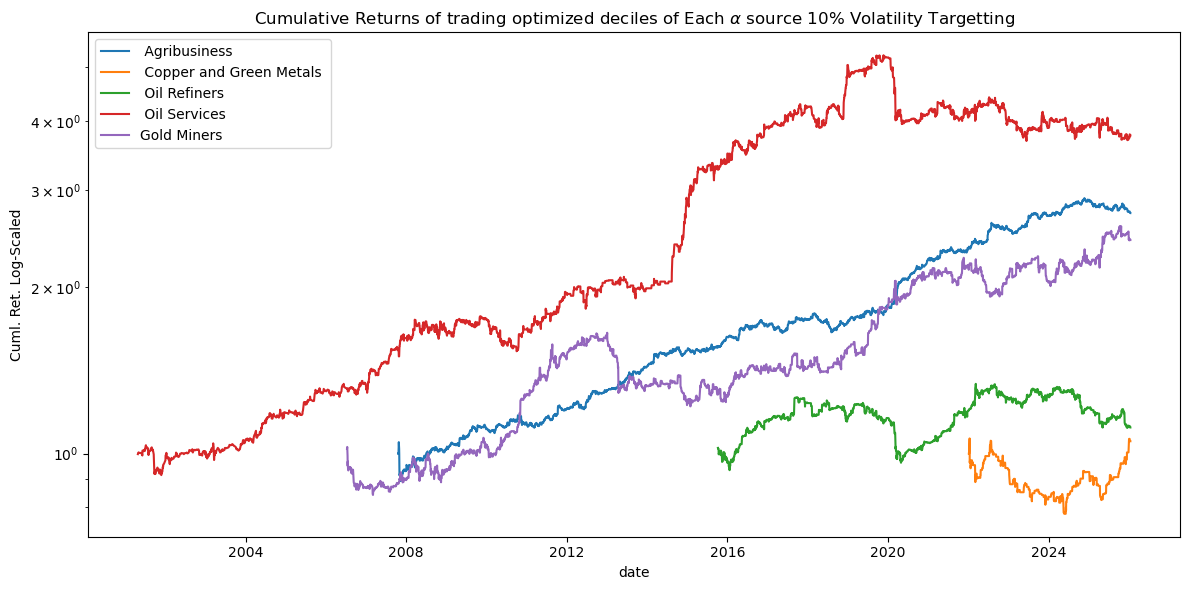

In [35]:
(df_name_rtn.
    reset_index().
    rename(columns = {"Name": ""}).
    pivot(index = "date", columns = "", values = "rtn").
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        figsize = (12,6),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = r"Cumulative Returns of trading optimized deciles of Each $\alpha$ source 10% Volatility Targetting"))

plt.tight_layout()

In [36]:
df_perf_name_rtn = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "rtn").
    rename(columns = {("date", ""): "date"}).
    drop(columns = ["fut_ticker"]).
    dropna().
    groupby(["date", "Name"]).
    agg("mean").
    assign(group = "perf"))

In [46]:
display(pd.concat([
    df_perf_name_rtn, df_name_rtn]).
    reset_index().
    rename(columns = {"rtn": "raw_rtn"}).
    assign(adj_rtn = lambda x: np.where(x.raw_rtn == 0, np.nan, x.raw_rtn)).
    melt(id_vars = ["date", "Name", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["Name", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"   : "Vol. Target",
        "variable": ""}).
    replace({
        "perf"      : "Perfect Targetting",
        "vol_target": "Vol Targetting",
        "raw_rtn"   : "Raw Sharpe",
        "adj_rtn"   : "Adj Sharpe"}).
    pivot(index = "Name", columns = ["Vol. Target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Vol. Target               Perfect Targetting            Vol Targetting  \
                                  Adj Sharpe Raw Sharpe     Adj Sharpe   
Name                                                                     
 Agribusiness                          1.244      1.171          1.272   
 Copper and Green Metals               0.824      0.369          0.379   
 Oil Refiners                          0.531      0.395          0.249   
 Oil Services                          1.075      0.750          0.976   
Gold Miners                            0.962      0.627          0.791   

Vol. Target                           
                          Raw Sharpe  
Name                                  
 Agribusiness                  1.198  
 Copper and Green Metals       0.170  
 Oil Refiners                  0.185  
 Oil Services                  0.681  
Gold Miners                    0.515

In [ ]:
.
    assign(adj_rtn = lambda x: np.where(x.raw_rtn == 0, np.nan, x.raw_rtn)).
    melt(id_vars = ["date", "Name", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["Name", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"   : "Vol. Target",
        "variable": ""}).
    replace({
        "perf"      : "Perfect Targetting",
        "vol_target": "Vol Targetting",
        "raw_rtn"   : "Raw Sharpe",
        "adj_rtn"   : "Adj Sharpe"}).
    pivot(index = "Name", columns = ["Vol. Target", ""], values = "value").
    apply(lambda x: np.round(x,3))

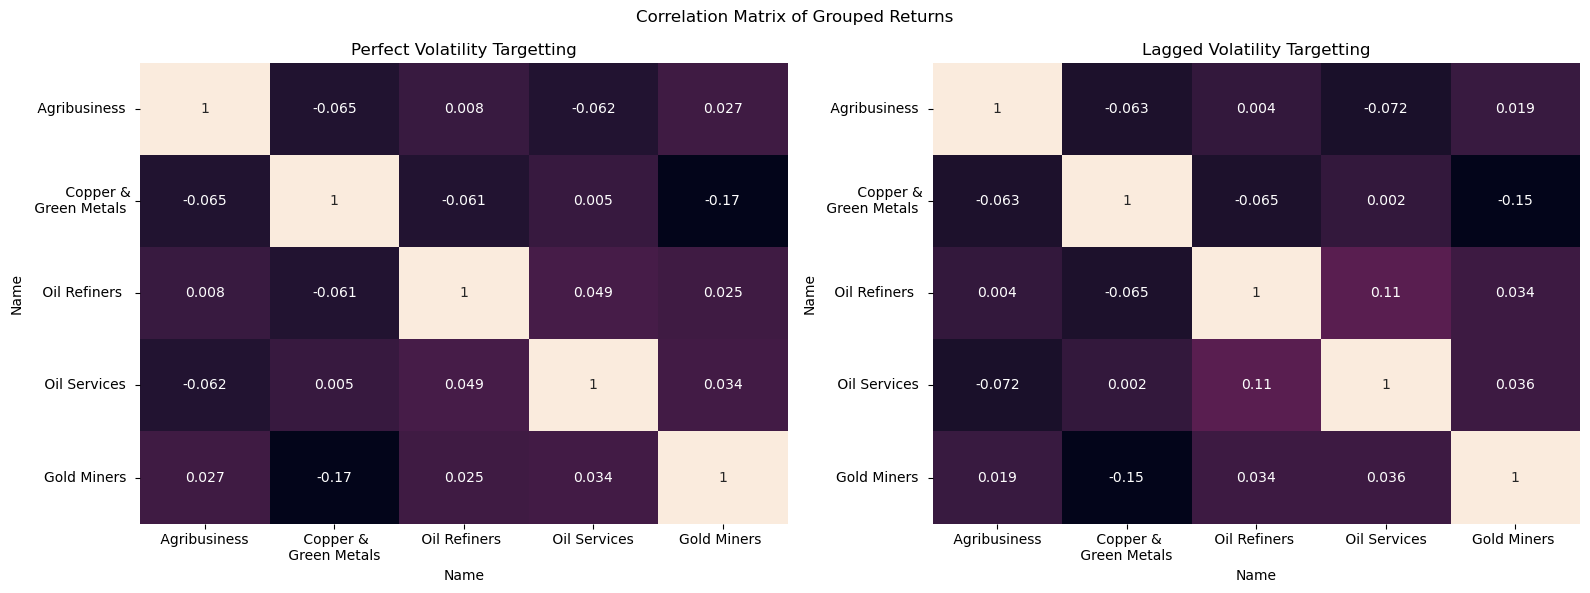

In [38]:
df_combined = (pd.concat([
    df_perf_name_rtn, df_name_rtn]).
    reset_index().
    assign(Name = lambda x: x.Name.str.replace("and", "&\n")))

groups    = df_combined.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups), figsize = (16,6)) 

renamer = {
    "perf"      : "Perfect Volatility Targetting",
    "vol_target": "Lagged Volatility Targetting"}

for group, ax in zip(groups, axes.flatten()): 

    df_corr = (df_combined.query(
        "group == @group").
        pivot(index = "date", columns = "Name", values = "rtn").
        corr().
        apply(lambda x: np.round(x,3)))

    sns.heatmap(
        data  = df_corr,
        cbar  = False,
        annot = True,
        ax    = ax)

    ax.set_title(renamer[group])

fig.suptitle("Correlation Matrix of Grouped Returns")
plt.tight_layout()

In [39]:
df_lagged = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "lagged_rtn"))

df_perf = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "perf"))

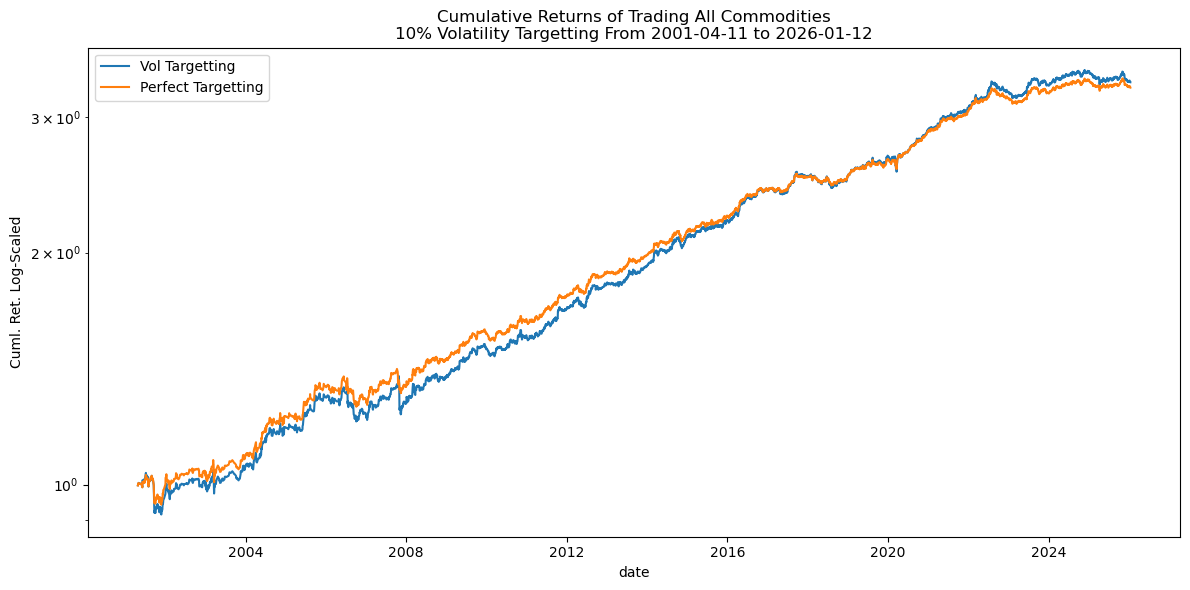

In [40]:
df_combined = (df_lagged.merge(
    right = df_perf, how = "inner", on = ["date"]).
    dropna())


(df_combined.
    apply(lambda x: np.cumprod(1 + x)).
    rename(columns = {
        "lagged_rtn": "Vol Targetting",
        "perf"      : "Perfect Targetting"}).
    plot(
        logy    = True,
        figsize = (12,6),
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of Trading All Commodities\n10% Volatility Targetting From {} to {}".format(
            df_perf.index.min(),
            df_perf.index.max())))

plt.tight_layout()

In [41]:
(df_combined.reset_index().melt(
    id_vars = "date", value_name = "raw_rtn").
    assign(adj_rtn = lambda x: np.where(x.raw_rtn == 0, np.nan, x.raw_rtn)).
    melt(id_vars = ["date", "variable"], var_name = "rtn_group", value_name = "rtn_val").
    drop(columns = ["date"]).
    dropna().
    groupby(["variable", "rtn_group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    replace({
        "lagged_rtn": "Vol Targetted",
        "perf"      : "Perf Targetted"}).
    rename(columns = {"rtn_group": ""}).
    pivot(index = "variable", columns = "", values = "rtn_val").
    rename(columns = {
        "adj_rtn": "Adjusted Sharpe",
        "raw_rtn": "Raw Sharpe"}).
    apply(lambda x: np.round(x,3)))

,Adjusted Sharpe,Raw Sharpe
variable,,
Perf Targetted,1.277,1.275
Vol Targetted,1.153,1.151
